In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
df = pd.read_csv("../FactorGenerate/multi_factor_eval_20241023.csv")

# 转成 bp，方便看
df["long_short_bp"] = df["long_short"] * 10000
df["group_0_bp"] = df["group_0"] * 10000
df["group_1_bp"] = df["group_1"] * 10000
df["group_2_bp"] = df["group_2"] * 10000
df["group_3_bp"] = df["group_3"] * 10000
df["group_4_bp"] = df["group_4"] * 10000

df.head()

,factor,horizon,sample_rows,overall_ic,overall_rankic,mean_timeseries_ic,icir,mean_timeseries_rankic,rankicir,group_0,...,group_2,group_3,group_4,long_short,long_short_bp,group_0_bp,group_1_bp,group_2_bp,group_3_bp,group_4_bp
0,f2_trade_imbalance_5,30,35100,0.076027,0.089102,0.083841,1.816176,0.094967,1.819902,-0.000084,...,0.000020,0.000088,0.000122,0.000206,2.060048,-0.842904,-0.104912,0.204890,0.884159,1.217144
1,f2_trade_obi_linear_10,30,35100,0.088018,0.107555,0.100674,1.674766,0.117179,1.842813,-0.000113,...,0.000015,0.000084,0.000169,0.000282,2.820128,-1.128392,-0.190995,0.149226,0.836801,1.691737
2,f2_trade_imbalance_10,30,35100,0.076819,0.089908,0.088818,1.628931,0.099334,1.621171,-0.000067,...,0.000015,0.000069,0.000132,0.000199,1.993507,-0.672871,-0.137510,0.154203,0.693919,1.320636
3,f2_amount_imbalance_10,30,35100,0.076820,0.088293,0.088818,1.628793,0.096807,1.588783,-0.000058,...,0.000018,0.000077,0.000123,0.000182,1.816329,-0.582300,-0.238446,0.178597,0.766497,1.234029
4,f2_trade_imbalance_20,30,35100,0.080946,0.096693,0.095911,1.627027,0.108007,1.701321,-0.000074,...,0.000037,0.000064,0.000139,0.000213,2.130625,-0.738011,-0.304499,0.373031,0.635242,1.392615


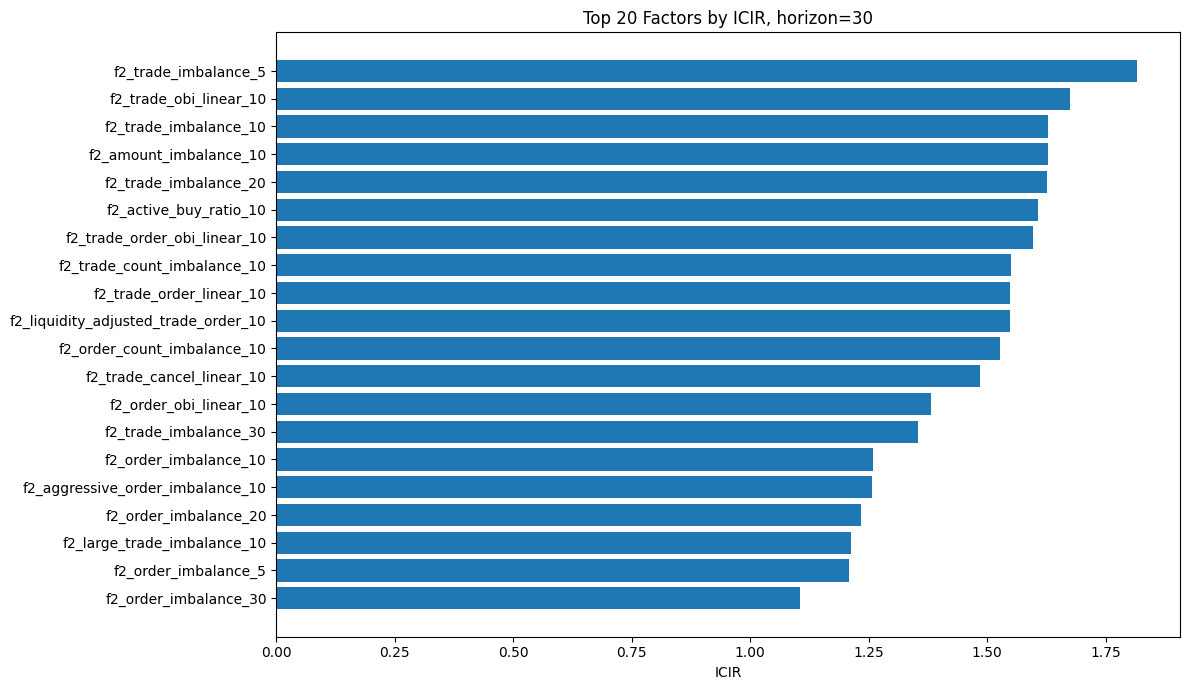

In [20]:
df30 = df[df["horizon"] == 30].copy()

top_icir = df30.sort_values("icir", ascending=False).head(20)

plt.figure(figsize=(12, 7))
plt.barh(top_icir["factor"][::-1], top_icir["icir"][::-1])
plt.xlabel("ICIR")
plt.title("Top 20 Factors by ICIR, horizon=30")
plt.tight_layout()
plt.show()

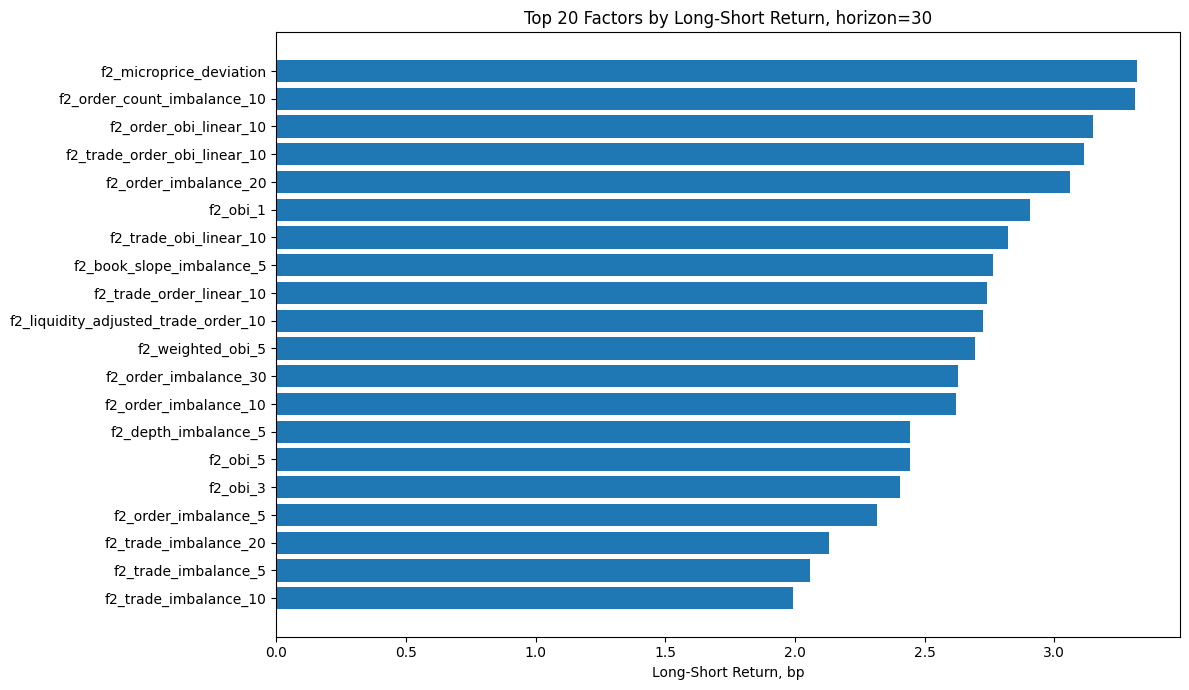

In [21]:
top_ls = df30.sort_values("long_short_bp", ascending=False).head(20)

plt.figure(figsize=(12, 7))
plt.barh(top_ls["factor"][::-1], top_ls["long_short_bp"][::-1])
plt.xlabel("Long-Short Return, bp")
plt.title("Top 20 Factors by Long-Short Return, horizon=30")
plt.tight_layout()
plt.show()

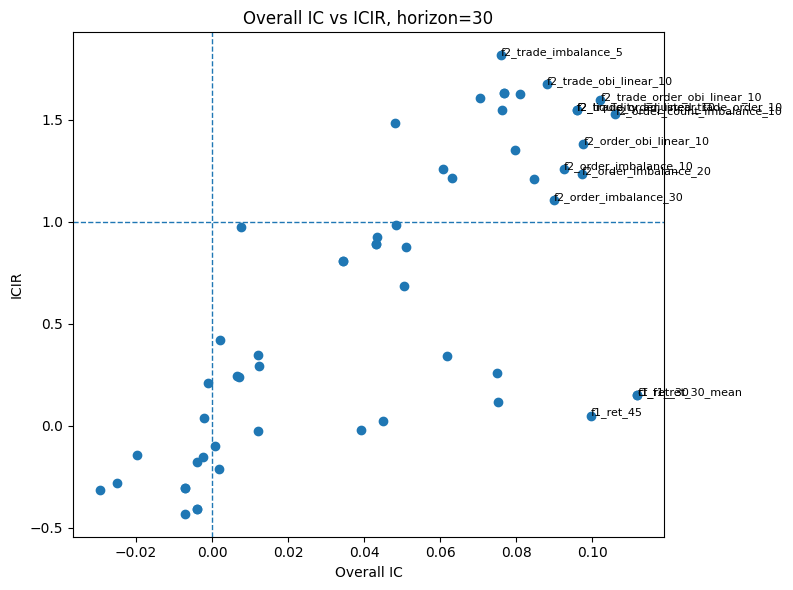

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(df30["overall_ic"], df30["icir"])

for _, row in df30.iterrows():
    if row["icir"] > 1.7 or row["overall_ic"] > 0.085:
        plt.text(row["overall_ic"], row["icir"], row["factor"], fontsize=8)

plt.xlabel("Overall IC")
plt.ylabel("ICIR")
plt.title("Overall IC vs ICIR, horizon=30")
plt.axhline(1, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

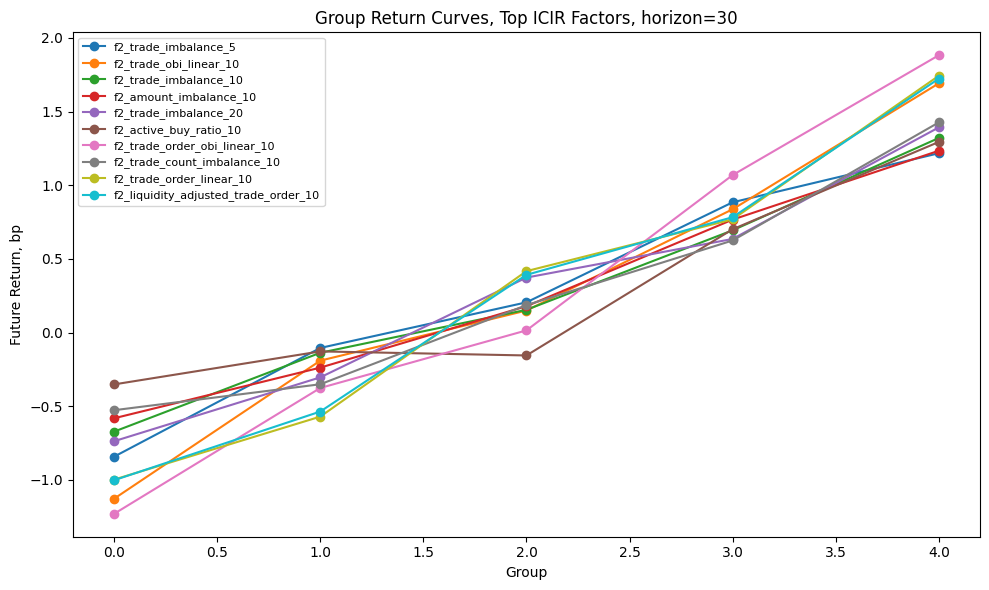

In [23]:
top_factors = df30.sort_values("icir", ascending=False).head(10)["factor"].tolist()

plt.figure(figsize=(10, 6))

for factor in top_factors:
    row = df30[df30["factor"] == factor].iloc[0]
    y = [
        row["group_0_bp"],
        row["group_1_bp"],
        row["group_2_bp"],
        row["group_3_bp"],
        row["group_4_bp"],
    ]
    plt.plot([0, 1, 2, 3, 4], y, marker="o", label=factor)

plt.xlabel("Group")
plt.ylabel("Future Return, bp")
plt.title("Group Return Curves, Top ICIR Factors, horizon=30")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

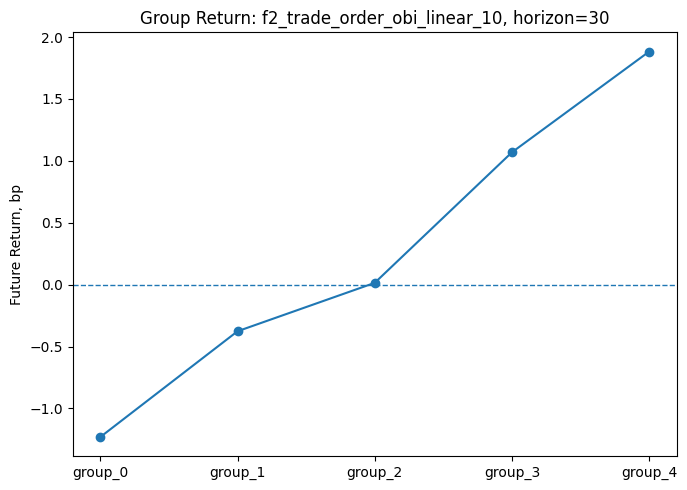

In [24]:
factor = "f2_trade_order_obi_linear_10"

row = df30[df30["factor"] == factor].iloc[0]

groups = ["group_0", "group_1", "group_2", "group_3", "group_4"]
returns = [row[g] * 10000 for g in groups]

plt.figure(figsize=(7, 5))
plt.plot(groups, returns, marker="o")
plt.ylabel("Future Return, bp")
plt.title(f"Group Return: {factor}, horizon=30")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

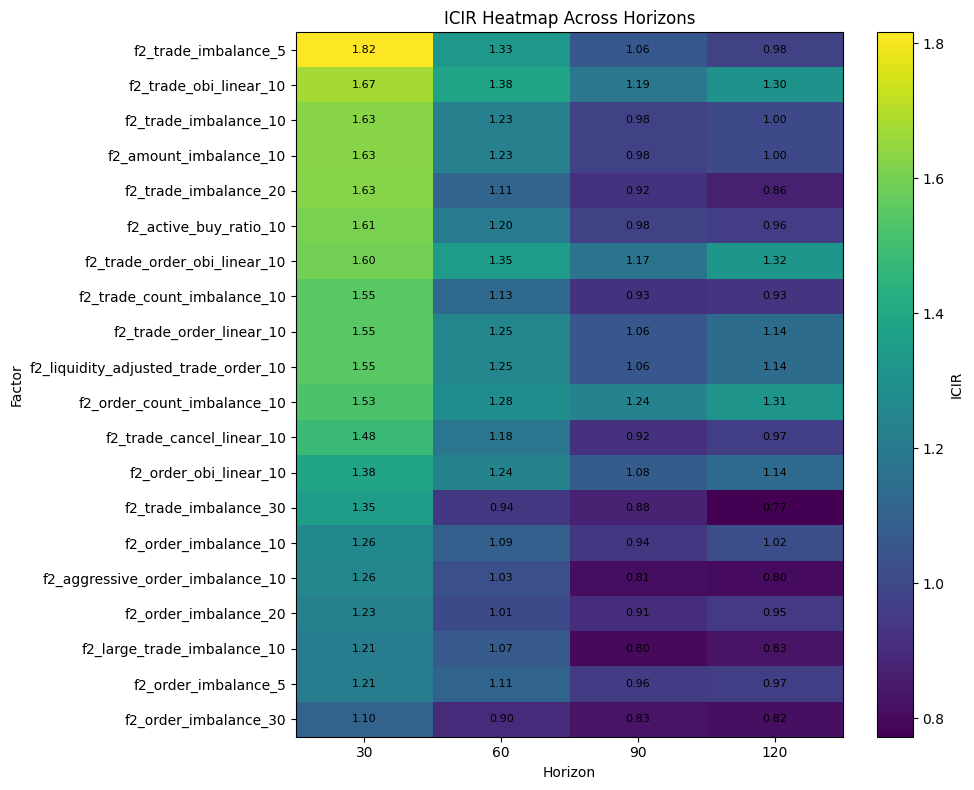

In [25]:
pivot_icir = df.pivot_table(
    index="factor",
    columns="horizon",
    values="icir"
)

# 只看 horizon=30 下 ICIR 排名前 20 的因子
top20_factors = (
    df[df["horizon"] == 30]
    .sort_values("icir", ascending=False)
    .head(20)["factor"]
)

pivot_top = pivot_icir.loc[top20_factors]

plt.figure(figsize=(10, 8))
plt.imshow(pivot_top.values, aspect="auto")

plt.xticks(range(len(pivot_top.columns)), pivot_top.columns)
plt.yticks(range(len(pivot_top.index)), pivot_top.index)

plt.colorbar(label="ICIR")
plt.title("ICIR Heatmap Across Horizons")
plt.xlabel("Horizon")
plt.ylabel("Factor")

for i in range(pivot_top.shape[0]):
    for j in range(pivot_top.shape[1]):
        val = pivot_top.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [26]:
score_df = df30.copy()

score_df["rank_icir"] = score_df["icir"].rank(ascending=False)
score_df["rank_ls"] = score_df["long_short_bp"].rank(ascending=False)
score_df["combined_rank"] = score_df["rank_icir"] + score_df["rank_ls"]

score_df.sort_values("combined_rank")[
    [
        "factor",
        "overall_ic",
        "overall_rankic",
        "icir",
        "rankicir",
        "long_short_bp",
        "combined_rank",
    ]
].head(20)

,factor,overall_ic,overall_rankic,icir,rankicir,long_short_bp,combined_rank
1,f2_trade_obi_linear_10,0.088018,0.107555,1.674766,1.842813,2.820128,9.0
6,f2_trade_order_obi_linear_10,0.102133,0.123859,1.596633,1.619278,3.113541,11.0
10,f2_order_count_imbalance_10,0.106108,0.138654,1.526083,1.562527,3.313603,13.0
12,f2_order_obi_linear_10,0.097684,0.123910,1.380804,1.452842,3.149386,16.0
8,f2_trade_order_linear_10,0.095971,0.115028,1.548670,1.523797,2.741737,18.0
9,f2_liquidity_adjusted_trade_order_10,0.095959,0.115464,1.547727,1.506829,2.726288,20.0
0,f2_trade_imbalance_5,0.076027,0.089102,1.816176,1.819902,2.060048,20.0
16,f2_order_imbalance_20,0.097225,0.122549,1.233279,1.208093,3.061040,22.0
4,f2_trade_imbalance_20,0.080946,0.096693,1.627027,1.701321,2.130625,23.0
2,f2_trade_imbalance_10,0.076819,0.089908,1.628931,1.621171,1.993507,23.0
